# ViDoRe EN -> RU

Translation pipeline.

In [1]:
!pip -q uninstall -y numpy scipy pandas pillow opencv-python opencv-python-headless opencv-contrib-python
!pip -q install --no-cache-dir --force-reinstall "numpy==1.26.4" "scipy==1.13.1" "pandas==2.2.2" "pillow==11.3.0" "PyYAML==6.0.2" "requests==2.32.4" "fsspec[http]==2025.3.0" "protobuf<6" "opencv-python-headless==4.10.0.84"
!pip -q install -U "transformers>=4.46" tokenizers accelerate datasets sentencepiece tqdm matplotlib langchain-text-splitters "langchain==0.3.27"
!pip -q install --no-cache-dir --force-reinstall "paddlepaddle-gpu==2.6.2" "paddleocr==2.7.3"
!pip -q install -U easyocr
!pip -q install --no-cache-dir --force-reinstall "numpy==1.26.4" "scipy==1.13.1" "pandas==2.2.2" "pillow==11.3.0" "PyYAML==6.0.2" "requests==2.32.4" "fsspec[http]==2025.3.0" "protobuf<6" "opencv-python-headless==4.10.0.84"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 31.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 277.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 260.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.6/79.6 kB 341.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 371.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 405.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 404.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 401.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 767.5/767.5 kB 417.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.8/64.8 kB 334.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 366.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 396.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
import json, hashlib
from pathlib import Path

import numpy as np
import torch
import os
from datasets import load_dataset, Dataset, Image as HFImage, load_from_disk
from PIL import Image, ImageDraw, ImageFont
from tqdm.auto import tqdm
from transformers import MarianTokenizer, MarianMTModel, AutoTokenizer, AutoModelForSeq2SeqLM
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')


/usr/local/lib/python3.12/dist-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.7.0) or chardet (7.4.3)/charset_normalizer (3.4.7) doesn't match a supported version!
  warnings.warn(


Mounted at /content/drive


In [2]:
#WORK_DIR = Path('/content/drive/MyDrive/vidore_ru_work')

WORK_DIR = Path('vidore_ru_work')

TRAIN_DATASET_ID = 'vidore/colpali_train_set'
TRAIN_SPLIT = 'train'
TEST_DATASET_IDS = ['vidore/docvqa_test_subsampled']
TEST_SPLIT = 'test'

# debug: 5 / 5. full: None / None
MAX_TRAIN = None
MAX_TEST = None

BATCH_SIZE = 64
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
MODEL_NAME = 'Helsinki-NLP/opus-mt-en-ru' #'facebook/nllb-200-distilled-600M'

WORK_DIR.mkdir(parents=True, exist_ok=True)
print('device:', DEVICE)


device: cuda


In [3]:
def read_jsonl(path):
    return [json.loads(x) for x in Path(path).read_text(encoding='utf-8').splitlines() if x.strip()]

## 1. Download original images + metadata

In [4]:
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"

In [ ]:
def read_jsonl(path):
    return [json.loads(x) for x in Path(path).read_text(encoding='utf-8').splitlines() if x.strip()]

def save_dataset(ds_id, split, name, limit):
    img_dir = WORK_DIR / 'original_images' / name
    meta_path = WORK_DIR / 'original_metadata' / f'{name}.jsonl'
    done_path = WORK_DIR / 'original_metadata' / f'{name}.done'
    img_dir.mkdir(parents=True, exist_ok=True)
    meta_path.parent.mkdir(parents=True, exist_ok=True)

    if limit is not None and meta_path.exists() and len(read_jsonl(meta_path)) >= limit:
        print('already saved', len(read_jsonl(meta_path)), name)
        return
    if limit is None and meta_path.exists() and done_path.exists():
        print('already saved full', len(read_jsonl(meta_path)), name)
        return

    ds = load_dataset(ds_id, split=split)
    if limit is not None:
        ds = ds.select(range(min(limit, len(ds))))

    with meta_path.open('w', encoding='utf-8') as f:
        for i, row in enumerate(tqdm(ds, desc=name)):
            img_path = img_dir / f'{i}.jpg'
            row['image'].convert('RGB').save(img_path)
            meta = {k: json.dumps(v) for k, v in dict(row).items() if k != 'image'}
            meta.update({'row_id': i, 'split': name, 'source_dataset': ds_id, 'source_split': split, 'original_image_path': str(img_path)})
            f.write(json.dumps(meta, ensure_ascii=False) + '\n')
    if limit is None:
        done_path.write_text(str(len(ds)), encoding='utf-8')
    print('saved', len(ds), name)

save_dataset(TRAIN_DATASET_ID, TRAIN_SPLIT, 'train', MAX_TRAIN)
for ds_id in TEST_DATASET_IDS:
    save_dataset(ds_id, TEST_SPLIT, 'test_' + ds_id, MAX_TEST)


## 2. OCR with PaddleOCR worker

In [18]:
import subprocess, time

NUM_OCR_SHARDS = 2

def read_jsonl(path):
    return [json.loads(x) for x in Path(path).read_text(encoding='utf-8').splitlines() if x.strip()]

def line_count(path):
    path = Path(path)
    return 0 if not path.exists() else sum(1 for _ in path.open(encoding='utf-8'))

def run_ocr_split(split):
    meta = read_jsonl(WORK_DIR / 'original_metadata' / f'{split}.jsonl')
    shard_sizes = [sum(1 for r in meta if int(r['row_id']) % NUM_OCR_SHARDS == sid) for sid in range(NUM_OCR_SHARDS)]

    procs = []
    for sid in range(NUM_OCR_SHARDS):
        cmd = ['python', 'ocr_paddle_worker.py', '--work-dir', str(WORK_DIR), '--split', split, '--num-shards', str(NUM_OCR_SHARDS), '--shard-id', str(sid), '--det-limit', '960']
        print(' '.join(cmd))
        procs.append(subprocess.Popen(cmd))

    while any(p.poll() is None for p in procs):
        counts = [line_count(WORK_DIR / 'ocr' / f'{split}.shard{sid}.jsonl') for sid in range(NUM_OCR_SHARDS)]
        print('progress', split, ' | '.join(f'shard{sid}: {counts[sid]}/{shard_sizes[sid]}' for sid in range(NUM_OCR_SHARDS)))
        time.sleep(20)

    for p in procs:
        assert p.returncode == 0

    rows = []
    for sid in range(NUM_OCR_SHARDS):
        rows += read_jsonl(WORK_DIR / 'ocr' / f'{split}.shard{sid}.jsonl')
    rows = sorted(rows, key=lambda x: x['row_id'])

    out = WORK_DIR / 'ocr' / f'{split}.jsonl'
    with out.open('w', encoding='utf-8') as f:
        for r in rows:
            f.write(json.dumps(r, ensure_ascii=False) + '\n')
    print('merged', len(rows), out)

In [ ]:
run_ocr_split('train')


python ocr_paddle_worker.py --work-dir vidore_ru_work --split train --num-shards 3 --shard-id 0 --det-limit 960
python ocr_paddle_worker.py --work-dir vidore_ru_work --split train --num-shards 3 --shard-id 1 --det-limit 960
python ocr_paddle_worker.py --work-dir vidore_ru_work --split train --num-shards 3 --shard-id 2 --det-limit 960
progress train shard0: 0/39399 | shard1: 0/39398 | shard2: 0/39398
progress train shard0: 13/39399 | shard1: 14/39398 | shard2: 11/39398
progress train shard0: 31/39399 | shard1: 33/39398 | shard2: 28/39398
progress train shard0: 48/39399 | shard1: 48/39398 | shard2: 42/39398
progress train shard0: 61/39399 | shard1: 63/39398 | shard2: 61/39398
progress train shard0: 77/39399 | shard1: 81/39398 | shard2: 84/39398
progress train shard0: 96/39399 | shard1: 102/39398 | shard2: 102/39398
progress train shard0: 116/39399 | shard1: 121/39398 | shard2: 120/39398
progress train shard0: 134/39399 | shard1: 140/39398 | shard2: 144/39398
progress train shard0: 151/39

In [8]:
#!cp /content/drive/MyDrive/vidore_ru_work.zip /content/
#!unzip -q /content/vidore_ru_work.zip -d /content/

In [19]:
TEST_SPLIT_NAME = 'test_vidore_docvqa_test_subsampled'
TEST_META = WORK_DIR / 'original_metadata' / 'test_vidore' / 'docvqa_test_subsampled.jsonl'
(WORK_DIR / 'original_metadata' / f'{TEST_SPLIT_NAME}.jsonl').write_text(TEST_META.read_text(encoding='utf-8'), encoding='utf-8')
run_ocr_split('test_vidore_docvqa_test_subsampled')

python ocr_paddle_worker.py --work-dir vidore_ru_work --split test_vidore_docvqa_test_subsampled --num-shards 2 --shard-id 0 --det-limit 960
python ocr_paddle_worker.py --work-dir vidore_ru_work --split test_vidore_docvqa_test_subsampled --num-shards 2 --shard-id 1 --det-limit 960
progress test_vidore_docvqa_test_subsampled shard0: 0/250 | shard1: 0/250
progress test_vidore_docvqa_test_subsampled shard0: 64/250 | shard1: 60/250
progress test_vidore_docvqa_test_subsampled shard0: 149/250 | shard1: 148/250
progress test_vidore_docvqa_test_subsampled shard0: 238/250 | shard1: 233/250
merged 500 vidore_ru_work/ocr/test_vidore_docvqa_test_subsampled.jsonl


## 3. Translate + render Russian images

In [20]:
!cp -r /content/drive/MyDrive/ocr/ /content/vidore_ru_work/

In [27]:
import matplotlib.font_manager as fm
import re
import html
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor


tok = AutoTokenizer.from_pretrained(MODEL_NAME)
mt = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME, torch_dtype=torch.float16).to(DEVICE).eval()
FONT_PATH = fm.findfont('DejaVu Sans')
BATCH_ROWS = 64 #16
BATCH_SIZE = 1024 #512
RENDER_WORKERS = 12 #8

TRANSLATION_CACHE = None

def sha(x):
    return hashlib.sha1(str(x).encode()).hexdigest()

def query(row):
    return str(row.get('query'))

def translate(texts):
    global TRANSLATION_CACHE
    cache_path = WORK_DIR / 'cache' / 'translation_cache.jsonl'
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    cache_path.touch(exist_ok=True)

    if TRANSLATION_CACHE is None:
        TRANSLATION_CACHE = {r['key']: r['ru'] for r in read_jsonl(cache_path)}

    cache = TRANSLATION_CACHE
    missing = sorted([x for x in texts if sha(x) not in cache], key=len) # для быстроты sort по len

    if 'nllb' in MODEL_NAME.lower():
        tok.src_lang = 'eng_Latn'
        forced_bos_token_id = tok.convert_tokens_to_ids('rus_Cyrl')
    else:
        forced_bos_token_id = None

    with cache_path.open('a', encoding='utf-8') as f:
        for i in range(0, len(missing), BATCH_SIZE):
            batch = missing[i:i+BATCH_SIZE]
            enc = tok(batch, return_tensors='pt', padding=True, truncation=True, max_length=96).to(DEVICE)
            with torch.no_grad():
                if forced_bos_token_id is None:
                    out = mt.generate(**enc, max_length=96)
                else:
                    out = mt.generate(**enc, max_length=96, forced_bos_token_id=forced_bos_token_id)
            for en, ru in zip(missing[i:i+BATCH_SIZE], tok.batch_decode(out, skip_special_tokens=True)):
                ru = html.unescape(ru).strip()
                cache[sha(en)] = ru.strip()
                f.write(json.dumps({'key': sha(en), 'en': en, 'ru': ru}, ensure_ascii=False) + '\n')

    return [cache[sha(x)] for x in texts]

def good_item(item):
    text = str(item.get('text', '')).strip()
    x1, y1, x2, y2 = item['box']
    w, h = x2 - x1, y2 - y1
    if not text or w < 4 or h < 5:
        return False
    if len(text) <= 1 and not any(c.isalnum() for c in text):
        return False
    if not any(c.isalnum() for c in text):
        return False
    if sum(c.isalnum() for c in text) < max(1, len(text) // 4):
        return False
    return True

def is_panel_label(text): #a), b), c)
    compact = re.sub(r'\s+', '', str(text).strip().lower())
    return bool(re.fullmatch(r'[a-z]\)', compact))


def is_numeric_text(text): # числа и спец. символы пропускаем
    compact = re.sub(r'\s+', '', str(text).strip().lower())
    return bool(re.fullmatch(r'[-+−–.,;:()\[\]/0-9%]+', compact))


def skip_text(text):
    return is_panel_label(text) or is_numeric_text(text)

def group_lines(items):
    items = [x for x in items if good_item(x) and not skip_text(x['text'])]
    items = sorted(items, key=lambda x: ((x['box'][1] + x['box'][3]) / 2, x['box'][0]))
    lines = []
    for item in items:
        x1, y1, x2, y2 = item['box']
        cy, h = (y1 + y2) / 2, y2 - y1
        placed = False
        for line in lines[-3:]:
            ly1, ly2 = line['y1'], line['y2']
            lcy, lh = (ly1 + ly2) / 2, ly2 - ly1
            last_x2 = max(p['box'][2] for p in line['items'])
            gap = x1 - last_x2
            if abs(cy - lcy) <= max(6, 0.6 * max(h, lh)) and gap <= max(30, 3 * max(h, lh)):
                line['items'].append(item)
                line['y1'], line['y2'] = min(line['y1'], y1), max(line['y2'], y2)
                placed = True
                break
        if not placed:
            lines.append({'y1': y1, 'y2': y2, 'items': [item]})

    out = []
    for line in lines:
        parts = sorted(line['items'], key=lambda x: x['box'][0])
        xs1, ys1, xs2, ys2 = zip(*[p['box'] for p in parts])
        out.append({
            'box': [min(xs1), min(ys1), max(xs2), max(ys2)],
            'text': ' '.join(str(p['text']).strip() for p in parts)
        })
    return out


def get_colors(img, box):
    x1, y1, x2, y2 = box
    crop = img.crop((x1, y1, x2, y2))
    arr = np.array(crop).reshape(-1, 3)

    # цвет фона примеро медиана
    bg_color = np.median(arr, axis=0)

    # цвет текста примеро медиана среди 5% наиболее отличных
    dist = np.linalg.norm(arr - bg_color, axis=1)
    top = arr[dist >= np.percentile(dist, 95)]
    fg_color = np.median(top, axis=0)

    return tuple(bg_color.astype(int)), tuple(fg_color.astype(int))

DUMMY_DRAW = ImageDraw.Draw(Image.new('RGB', (1, 1)))

def text_box(text, font):
    return DUMMY_DRAW.textbbox((0, 0), text, font=font)

def wrap_text(text, font, width):
    lines = []
    cur = ''
    for word in str(text).split():
        nxt = (cur + ' ' + word).strip()
        b = text_box(nxt, font)
        if cur and b[2] - b[0] > width:
            lines.append(cur)
            cur = word
        else:
            cur = nxt
    return lines + ([cur] if cur else [])

FONT_CACHE = {}

def get_font(size):
    if size not in FONT_CACHE:
        FONT_CACHE[size] = ImageFont.truetype(FONT_PATH, size)
    return FONT_CACHE[size]

def fit_text(text, box):
    x1, y1, x2, y2 = box
    w, h = max(1, x2 - x1), max(1, y2 - y1)
    for size in range(max(6, int(h * 1.2)), 5, -1):
        font = get_font(size)
        lines = wrap_text(text, font, w)
        line_h = max(1, int(size * 1.15))
        widths = [text_box(x, font)[2] - text_box(x, font)[0] for x in lines]
        if lines and max(widths) <= w and len(lines) * line_h <= h:
            return font, lines, line_h
    font = ImageFont.truetype(FONT_PATH, 6)
    return font, wrap_text(text, font, w), 7

def render_row(args):
    split, row, items, lines, en_lines, ru = args
    img_path = render(
        row['original_image_path'], lines,
        ru[1:], WORK_DIR / 'ru_images' / split / f"{row['row_id']}.jpg"
    )
    row.update({'image': img_path, 'image_ru_path': img_path,
                'query_ru': ru[0], 'ocr_text_en': '\n'.join(en_lines),
                'ocr_text_ru': '\n'.join(ru[1:]), 'ocr_items': items,
                'ocr_lines': lines, 'translation_ok': bool(ru[0].strip())})
    return row


def render(src, lines, ru_lines, dst):
    img = Image.open(src).convert('RGB')
    draw = ImageDraw.Draw(img)
    for line, text in zip(lines, ru_lines):
        x1, y1, x2, y2 = line['box']
        bg_color, fg_color = get_colors(img, line['box'])
        if np.linalg.norm(np.array(fg_color) - np.array(bg_color)) < 30:
            fg_color = (20, 20, 20)
        font, chunks, line_h = fit_text(text, line['box'])
        draw.rectangle([x1, y1, x2, y2], fill=bg_color)
        for j, chunk in enumerate(chunks):
            if y1 + j * line_h < y2:
                draw.text((x1, y1 + j * line_h), chunk, fill=fg_color, font=font)
    Path(dst).parent.mkdir(parents=True, exist_ok=True)
    img.save(dst)
    return str(dst)

def process(split):
    orig = read_jsonl(WORK_DIR / 'original_metadata' / f'{split}.jsonl')
    ocr = {r['row_id']: r['ocr_items'] for r in read_jsonl(WORK_DIR / 'ocr' / f'{split}.jsonl')}
    out_meta = WORK_DIR / 'translated_metadata' / f'{split}.jsonl'
    out_meta.parent.mkdir(parents=True, exist_ok=True)
    out_meta.touch(exist_ok=True)
    done = {r['row_id'] for r in read_jsonl(out_meta)}

    rows = [r for r in orig if r['row_id'] not in done]
    pack = []
    for row in rows:
        items = ocr.get(row['row_id'], [])
        lines = group_lines(items)
        pack.append((row, items, lines, [x['text'] for x in lines]))

    with out_meta.open('a', encoding='utf-8') as f:
        for i in tqdm(range(0, len(pack), BATCH_ROWS), desc='translate ' + split):
            batch = pack[i:i+BATCH_ROWS]
            texts, sizes = [], []

            for row, items, lines, en_lines in batch:
                cur = [query(row)] + en_lines
                texts += cur
                sizes.append(len(cur))

            ru_all = translate(texts)
            pos = 0
            jobs = []

            for (row, items, lines, en_lines), size in zip(batch, sizes):
                ru = ru_all[pos:pos+size]
                pos += size
                jobs.append((split, row, items, lines, en_lines, ru))

            with ProcessPoolExecutor(max_workers=RENDER_WORKERS) as ex:
                for row in ex.map(render_row, jobs):
                    f.write(json.dumps(row, ensure_ascii=False) + '\n')
                    f.flush()


    ds = Dataset.from_list(read_jsonl(out_meta)).cast_column('image', HFImage())
    ds.save_to_disk(WORK_DIR / 'hf_datasets' / split)
    print('saved', split, len(ds))


/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

In [28]:
#test
for p in sorted((WORK_DIR / 'original_metadata').glob('*test*.jsonl')):
    process(p.stem)

translate test_vidore_docvqa_test_subsampled: 0it [00:00, ?it/s]

Saving the dataset (0/1 shards):   0%|          | 0/500 [00:00<?, ? examples/s]

saved test_vidore_docvqa_test_subsampled 500


In [35]:
#train (для удобства обрабатываем в порядке 1:9:10)
orig = read_jsonl(WORK_DIR/'original_metadata'/'train.jsonl')
ocr = {r['row_id']: r for r in read_jsonl(WORK_DIR/'ocr'/'train.jsonl')}

n = len(orig)
parts = [('tr1', orig[:n//20]), ('tr2', orig[n//20:n//2]), ('tr3', orig[n//2:])]

for name, data in parts:
    if (WORK_DIR/'hf_datasets'/name).exists():
        print(f'{name} уже готов')
        continue

    (WORK_DIR/'original_metadata'/f'{name}.jsonl').write_text('\n'.join(json.dumps(x, ensure_ascii=False) for x in data))
    (WORK_DIR/'ocr'/f'{name}.jsonl').write_text('\n'.join(json.dumps(ocr[x['row_id']], ensure_ascii=False) for x in data if x['row_id'] in ocr))
    process(name)

tr1 уже готов


translate tr2:   0%|          | 0/790 [00:00<?, ?it/s]

Saving the dataset (0/34 shards):   0%|          | 0/53188 [00:00<?, ? examples/s]

saved tr2 53188


translate tr3:   0%|          | 0/924 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [36]:
from datasets import concatenate_datasets, load_from_disk

parts = [load_from_disk(WORK_DIR/'hf_datasets'/f'tr{i}') for i in (1, 2)]
full_ds = concatenate_datasets(parts)

full_ds.save_to_disk(WORK_DIR/'hf_datasets'/'train_merged')
print(len(full_ds))

Loading dataset from disk:   0%|          | 0/34 [00:00<?, ?it/s]

Saving the dataset (0/38 shards):   0%|          | 0/59097 [00:00<?, ? examples/s]

59097


## 4. Count

In [37]:
for p in sorted((WORK_DIR / 'original_metadata').glob('*.jsonl')):
    split = p.stem
    print(split)
    print('original  ', len(read_jsonl(p)))
    print('ocr       ', len(read_jsonl(WORK_DIR / 'ocr' / f'{split}.jsonl')))
    print('translated', len(read_jsonl(WORK_DIR / 'translated_metadata' / f'{split}.jsonl')))


test_vidore_docvqa_test_subsampled
original   500
ocr        500
translated 500
tr1
original   5909
ocr        5909
translated 5909
tr2
original   53188
ocr        53188
translated 53188
tr3
original   59098
ocr        59098
translated 1049
train
original   118195
ocr        118195
translated 1667


## 5. Preview

"Сопоставительные панели a, b, c и d, какая ведомость лучше всего описывает разницу в данных?"
"Какова продолжительность курса, упомянутого в образе?"
"Какова главная цель PTC в литиевых батареях?"


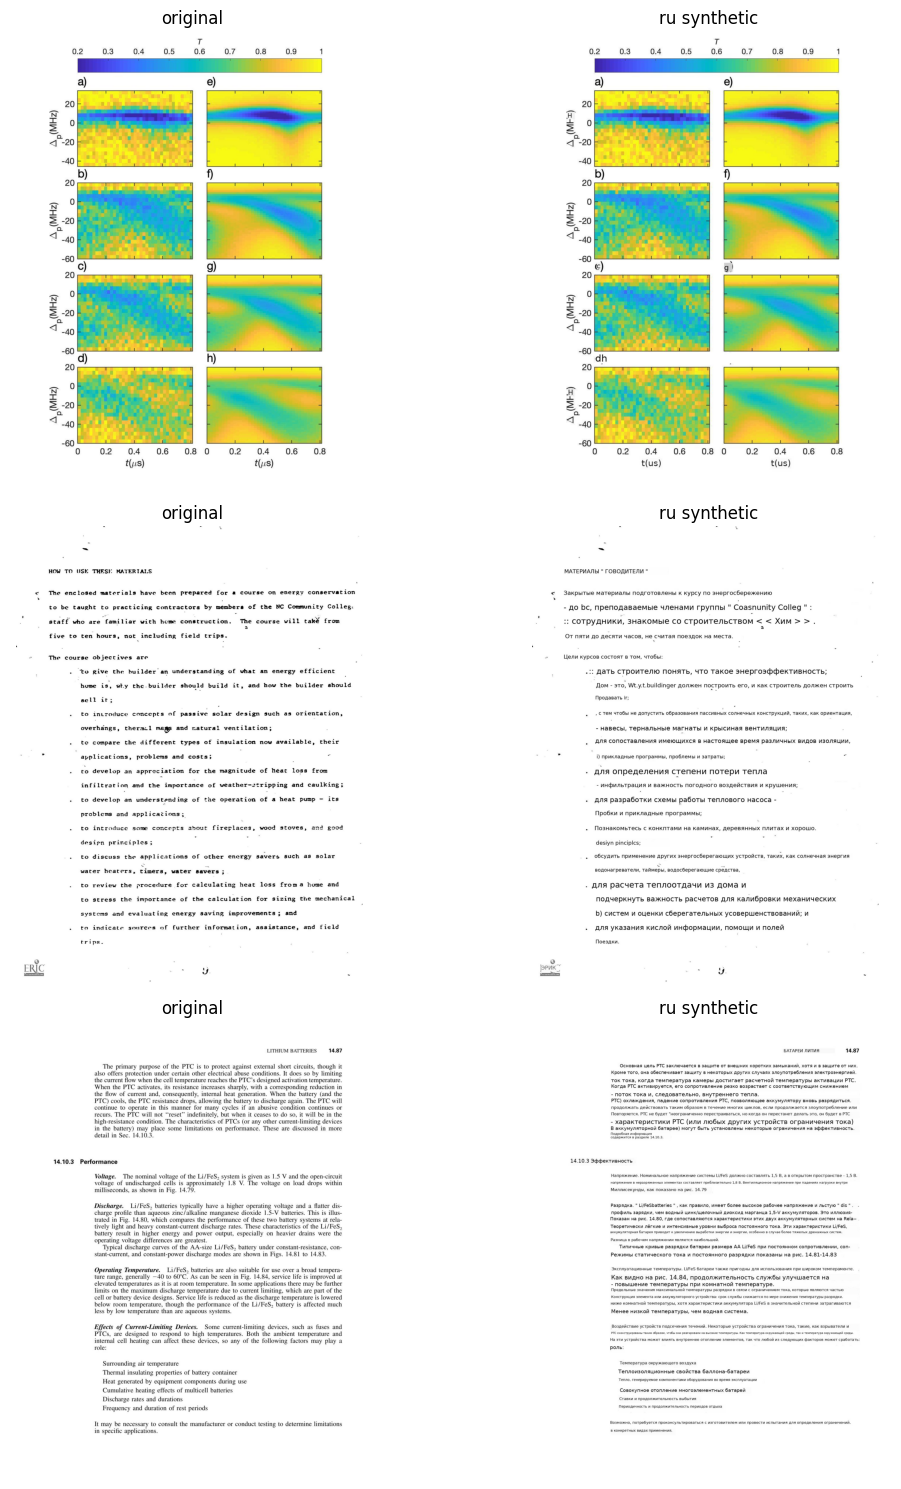

In [38]:
ds = load_from_disk(WORK_DIR / 'hf_datasets' / 'train')
n = min(3, len(ds))
fig, ax = plt.subplots(n, 2, figsize=(12, 5*n))
if n == 1:
    ax = [ax]
for i in range(n):
    row = ds[i]
    ax[i][0].imshow(Image.open(row['original_image_path']))
    ax[i][0].set_title('original')
    ax[i][0].axis('off')
    ax[i][1].imshow(row['image'])
    ax[i][1].set_title('ru synthetic')
    ax[i][1].axis('off')
    print(row['query_ru'])
plt.tight_layout()


In [40]:
!tar -cf /content/vidore_ru_result.tar -C /content/vidore_ru_work hf_datasets ru_images translated_metadata
!cp /content/vidore_ru_result.tar /content/drive/MyDrive/

Готово! Архив сохранен на Диске как vidore_ru_result.tar
